In [11]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
sns.set(style="whitegrid")

# Load normalized data (log-space, imputed)
df = pd.read_parquet("C:\\Users\\PC\\balnce-sheet-ml\\data\\processed\\wide_norm_0.parquet")

print("Shape:", df.shape)
print("Columns:", len(df.columns))
print("Companies (CIK):", df["cik"].nunique())



Shape: (10701, 104)
Columns: 104
Companies (CIK): 85


Periods per company — min/median/max: 1 66.0 125


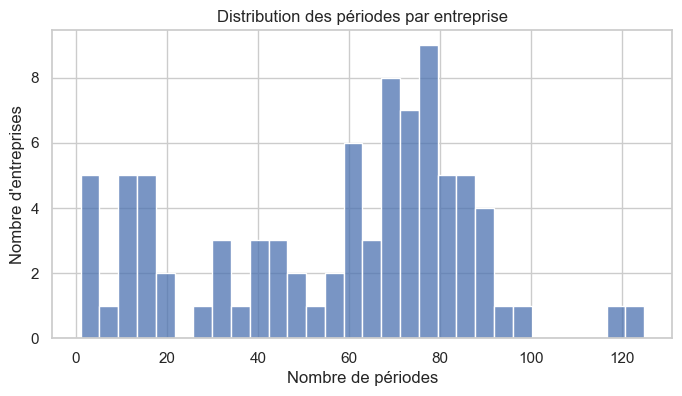

In [12]:
# Periods per company (unique reporting dates)
periods_per_company = df.groupby("cik")["end"].nunique()
print("Periods per company — min/median/max:", periods_per_company.min(), periods_per_company.median(), periods_per_company.max())

# Distribution of series length
plt.figure(figsize=(8,4))
sns.histplot(periods_per_company, bins=30)
plt.title("Distribution des périodes par entreprise")
plt.xlabel("Nombre de périodes")
plt.ylabel("Nombre d'entreprises")
plt.show()


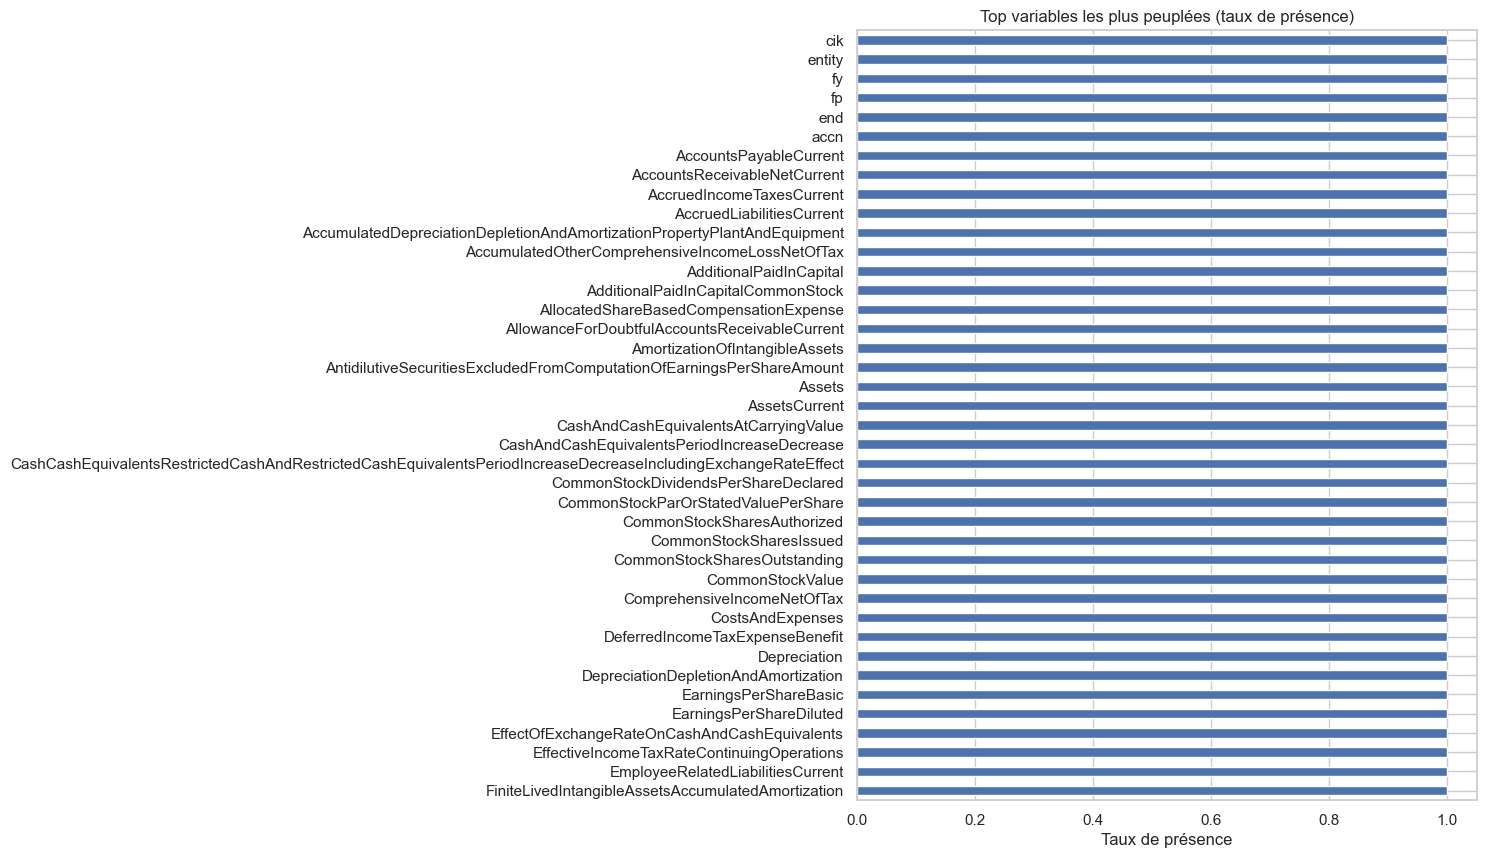

,presence
cik,1.0
entity,1.0
fy,1.0
fp,1.0
end,1.0
accn,1.0
AccountsPayableCurrent,1.0
AccountsReceivableNetCurrent,1.0
AccruedIncomeTaxesCurrent,1.0
AccruedLiabilitiesCurrent,1.0


In [13]:
# Variable coverage (presence ratio)
presence = df.notna().mean().sort_values(ascending=False)
top_vars = presence.head(40)
plt.figure(figsize=(8,10))
top_vars.plot(kind="barh")
plt.title("Top variables les plus peuplées (taux de présence)")
plt.xlabel("Taux de présence")
plt.gca().invert_yaxis()
plt.show()

# Quick table of top concepts (most populated)
top_vars.to_frame("presence").head(20)


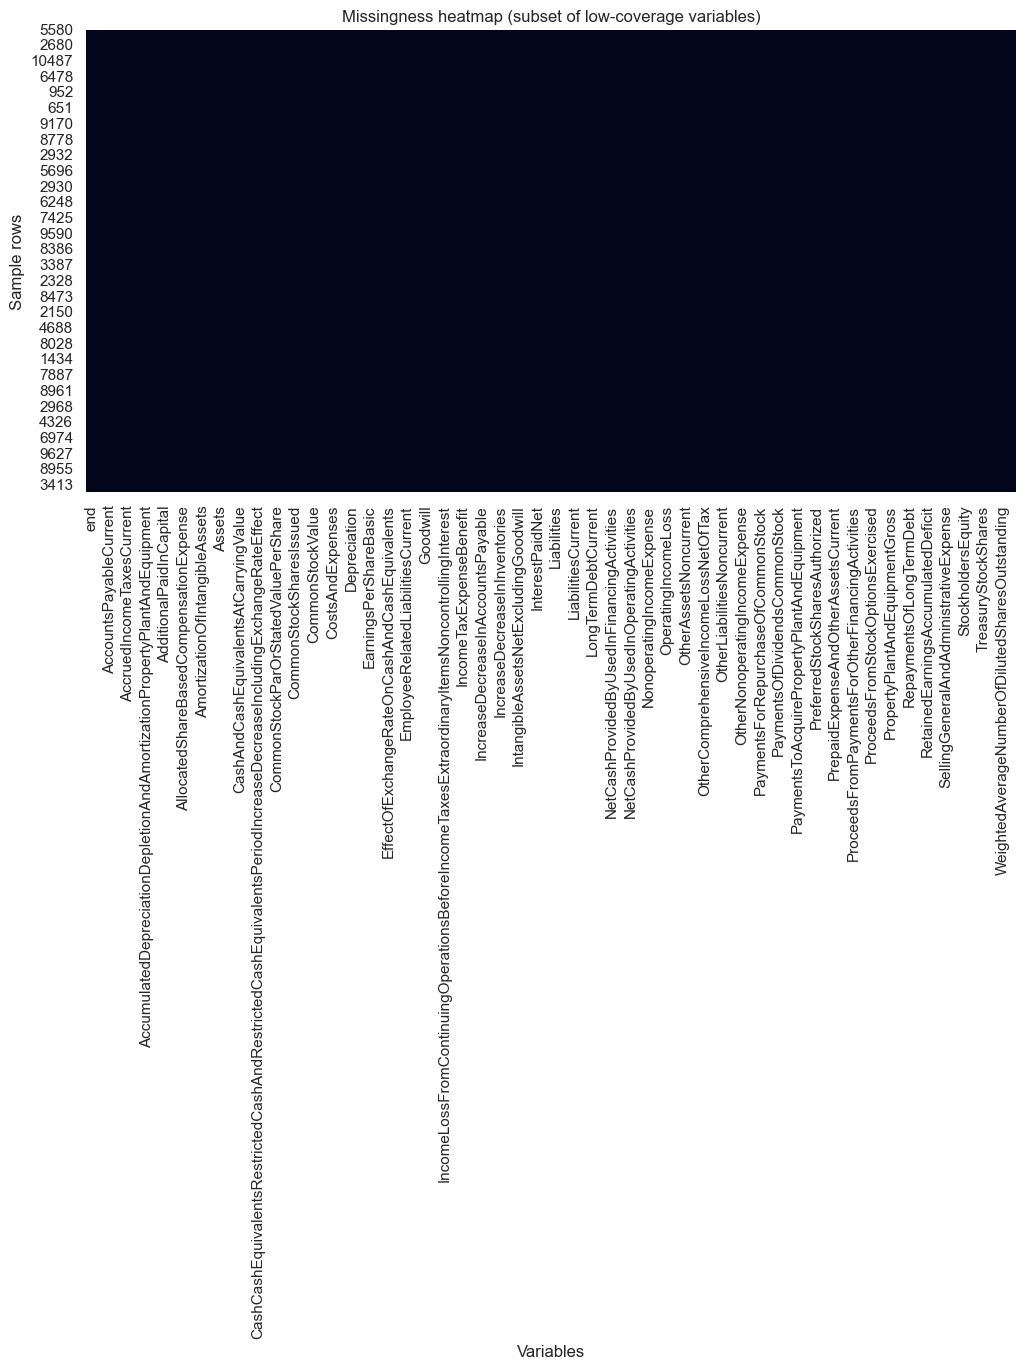

In [14]:
# For performance, sample a subset of rows and columns for heatmap
sample_rows = df.sample(n=min(1500, len(df)), random_state=42)
sample_cols = presence.tail(100).index  # the least populated 100 vars
plt.figure(figsize=(12,6))
sns.heatmap(sample_rows[sample_cols].isna(), cbar=False)
plt.title("Missingness heatmap (subset of low-coverage variables)")
plt.xlabel("Variables")
plt.ylabel("Sample rows")
plt.show()


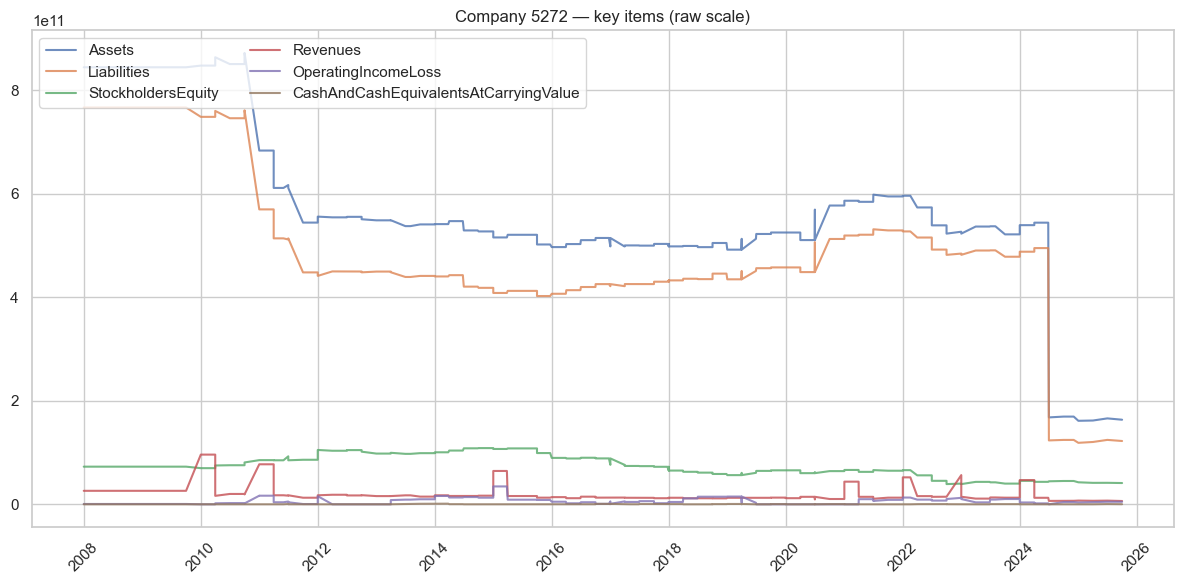

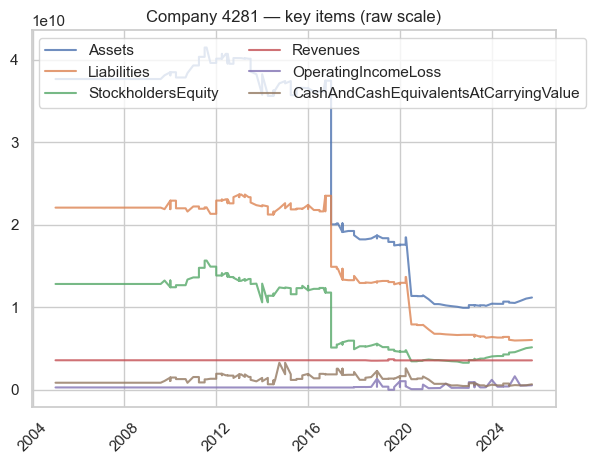

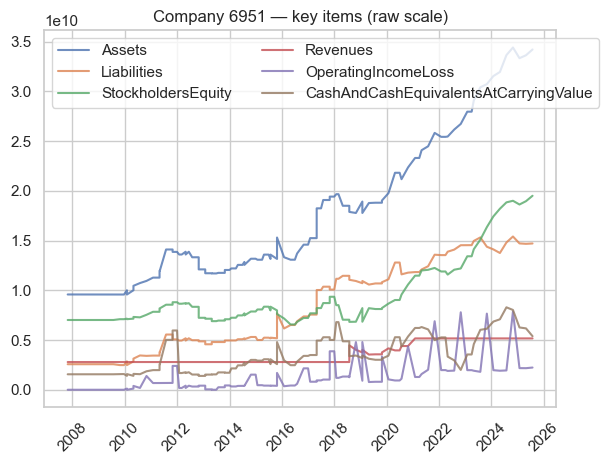

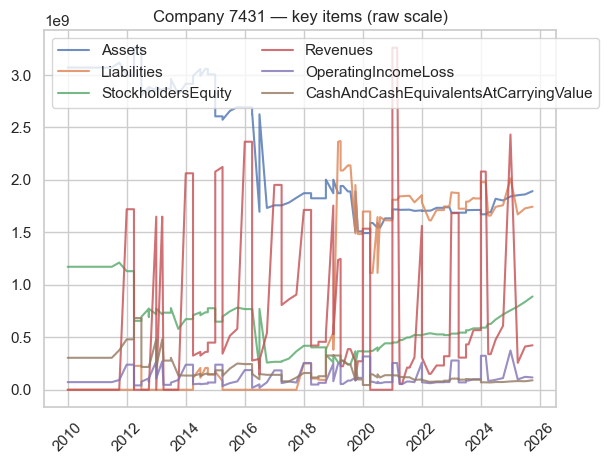

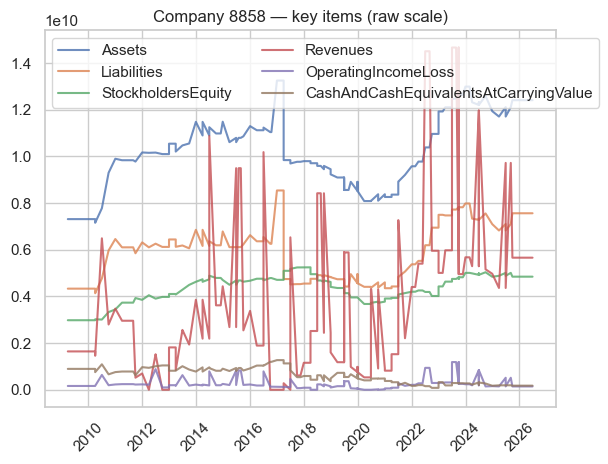

In [15]:
key_vars = [
    "Assets", "Liabilities", "StockholdersEquity",
    "Revenues", "OperatingIncomeLoss",
    "CashAndCashEquivalentsAtCarryingValue"
]

# Choose 5–10 representative companies by data richness
dense_companies = periods_per_company.sort_values(ascending=False).head(10).index.tolist()

# Plot trends (raw scale) for a few companies
n_to_plot = min(5, len(dense_companies))
plt.figure(figsize=(12,6))
for i, cik in enumerate(dense_companies[:n_to_plot], start=1):
    cdf = df[df["cik"] == cik].sort_values("end")
    plt.clf()
    for v in key_vars:
        if v in cdf.columns:
            plt.plot(cdf["end"], np.expm1(cdf[v]), label=v, alpha=0.8)
    plt.title(f"Company {cik} — key items (raw scale)")
    plt.legend(loc="upper left", ncol=2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [16]:
# Describe tables (raw scale)
desc = df[key_vars].apply(np.expm1).describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])
desc


,Assets,Liabilities,StockholdersEquity,Revenues,OperatingIncomeLoss,CashAndCashEquivalentsAtCarryingValue
count,1.070100e+04,1.070100e+04,1.070100e+04,1.070100e+04,1.070100e+04,1.070100e+04
mean,2.764393e+10,2.252676e+10,5.596648e+09,2.996362e+09,5.119861e+08,6.999284e+08
std,8.727142e+10,7.620261e+10,1.307873e+10,6.805203e+09,1.577038e+09,2.008557e+09
min,0.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
1%,9.337800e+04,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
5%,3.709601e+06,1.800000e+06,-1.000000e+00,-1.000000e+00,-1.000000e+00,9.281400e+04
25%,3.925820e+08,6.736607e+07,1.130820e+08,4.756800e+07,1.243000e+06,1.380300e+07
50%,2.447600e+09,1.405619e+09,6.824000e+08,7.790505e+08,5.562200e+07,1.009730e+08
75%,2.003800e+10,1.310800e+10,4.757155e+09,2.685954e+09,3.204030e+08,6.925850e+08
95%,9.124940e+10,7.824437e+10,2.613520e+10,1.603536e+10,2.010039e+09,3.004000e+09


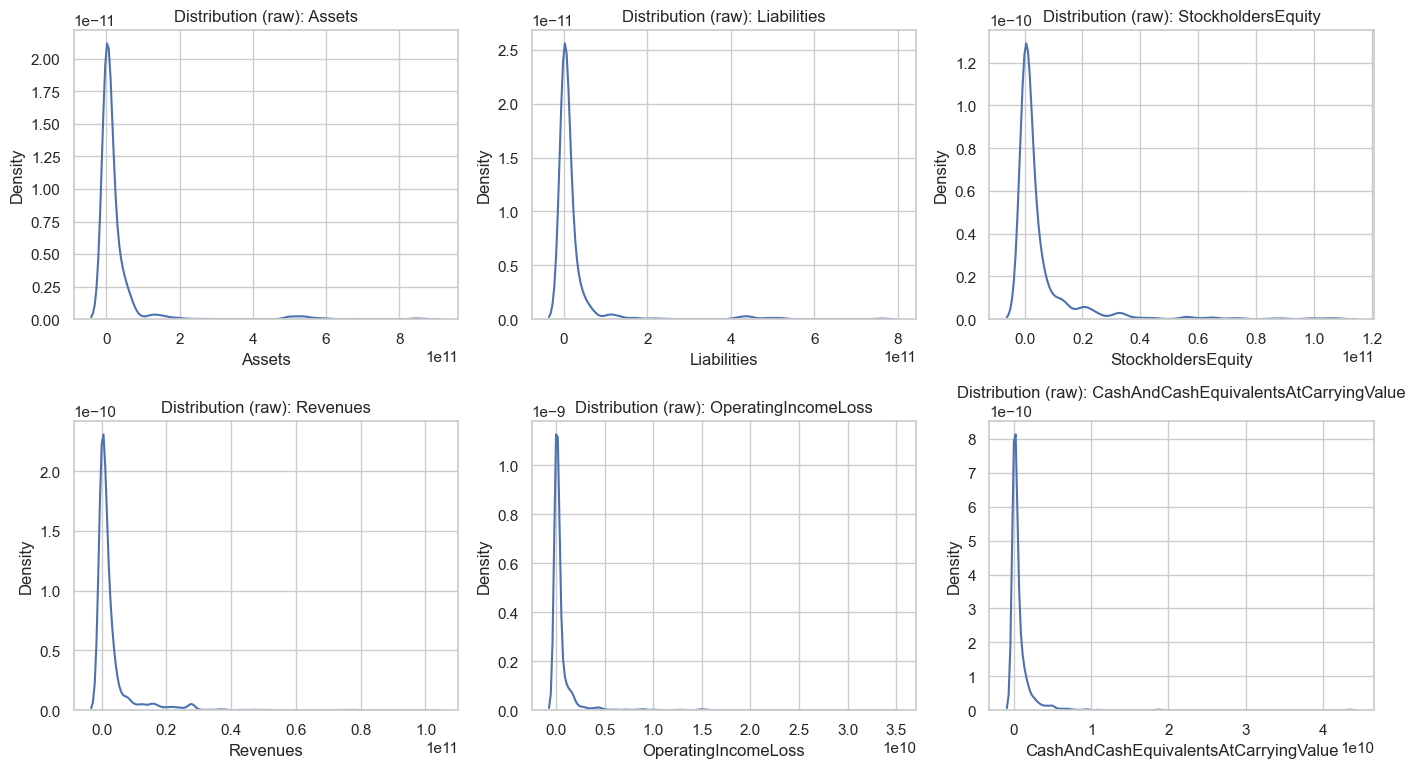

In [17]:
# Histograms / KDE for key variables (raw scale)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14,8))
axes = axes.flatten()
for ax, v in zip(axes, key_vars[:len(axes)]):
    if v in df.columns:
        sns.kdeplot(np.expm1(df[v].dropna()), ax=ax)
        ax.set_title(f"Distribution (raw): {v}")
        ax.set_xlabel(v)
        ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


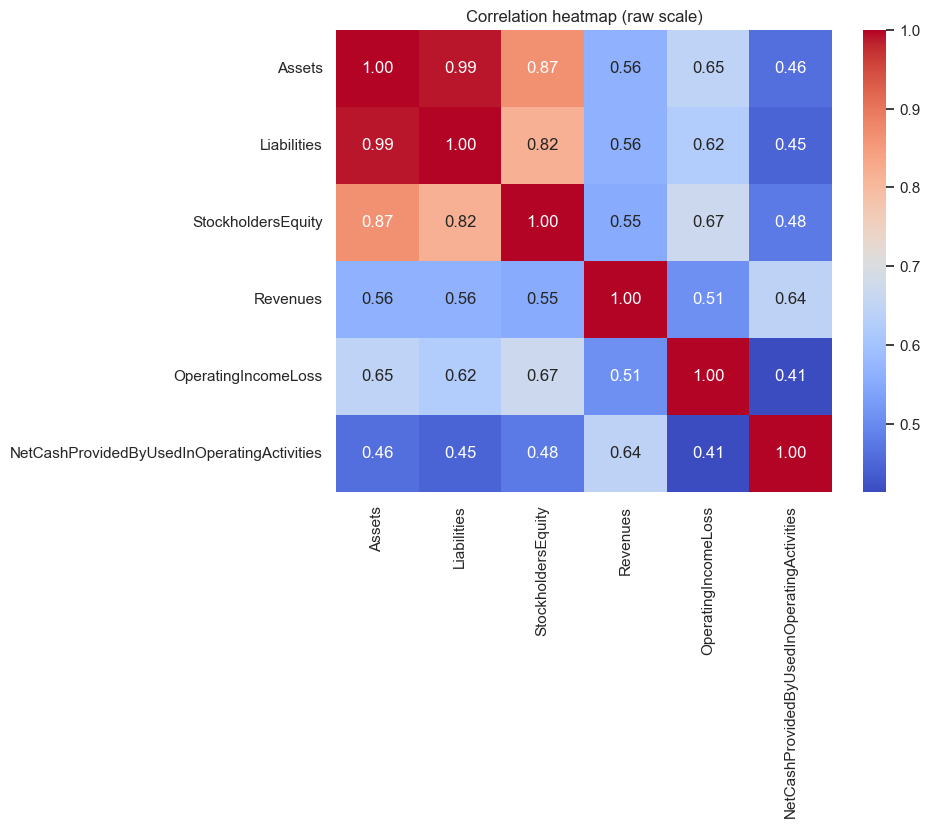

In [18]:
# Build a compact correlation set (raw scale for interpretability)
corr_vars = [
    "Assets", "Liabilities", "StockholdersEquity",
    "Revenues", "AccountsReceivableNet",
    "OperatingIncomeLoss", "NetCashProvidedByUsedInOperatingActivities"
]

avail = [v for v in corr_vars if v in df.columns]
corr_df = df[avail].apply(np.expm1)
corr = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap (raw scale)")
plt.show()


In [20]:
from statsmodels.tsa.stattools import adfuller

def adf_on_series(x):
    x = pd.Series(x).dropna()
    if len(x) < 10:
        return np.nan
    try:
        return adfuller(x, autolag="AIC")[1]  # p-value
    except:
        return np.nan

stationarity = {}
for v in key_vars:
    if v in df.columns:
        # Use log-space differences for stationarity proxy
        s = df.sort_values(["cik","end"]).groupby("cik")[v].apply(lambda x: x.diff())
        stationarity[v] = adf_on_series(s.values)

pd.Series(stationarity, name="ADF p-value").to_frame()


,ADF p-value
Assets,0.0
Liabilities,0.0
StockholdersEquity,0.0
Revenues,0.0
OperatingIncomeLoss,0.0
CashAndCashEquivalentsAtCarryingValue,0.0


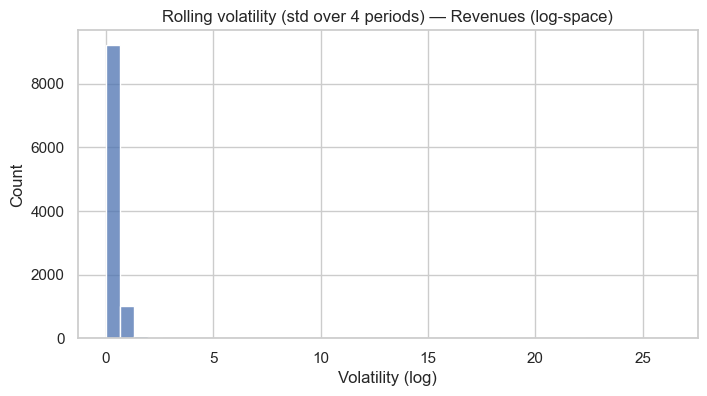

In [21]:
# Rolling std of Revenues (log-space), then show distribution of rolling vol
revs = df.sort_values(["cik","end"]).groupby("cik")["Revenues"].apply(lambda x: x.rolling(window=4, min_periods=3).std())
plt.figure(figsize=(8,4))
sns.histplot(revs.dropna(), bins=40)
plt.title("Rolling volatility (std over 4 periods) — Revenues (log-space)")
plt.xlabel("Volatility (log)")
plt.show()


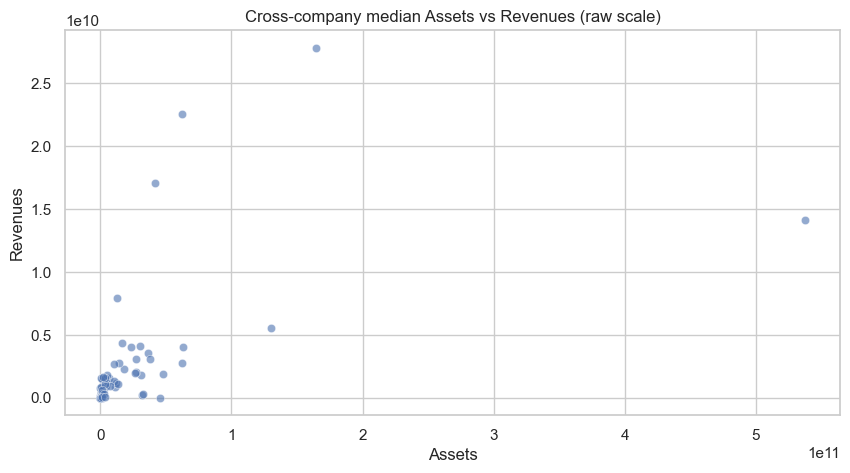

,n_companies
end,
<4,5
4–12,5
12–50,21
>50,54


In [23]:
# Compare median levels across companies (raw scale)
company_levels = df.groupby("cik")[["Assets","Liabilities","Revenues"]].median()
company_levels = company_levels.apply(np.expm1)

plt.figure(figsize=(10,5))
sns.scatterplot(x="Assets", y="Revenues", data=company_levels, alpha=0.6)
plt.title("Cross-company median Assets vs Revenues (raw scale)")
plt.show()

# Density of periods by company segments
bins = pd.cut(periods_per_company, bins=[0,4,12,50,200], labels=["<4","4–12","12–50",">50"])
seg_counts = bins.value_counts().sort_index()
seg_counts.to_frame("n_companies")
